
# pyEDITH Tutorial: Imaging Mode

This tutorial will guide you through using pyEDITH in imaging mode. We'll explore how to set up parameters, run the Exposure Time Calculator (ETC), and analyze the results.


## Before we start

Make sure you follow the instructions on the [Installation](https://pyedith.readthedocs.io/en/latest/installation.html) page.

## 1. Basic Usage

This section will explain how to use the premade ``umbrella'' functions in the code.

### 1.1 Setup and Imports

First, let's import the necessary modules and set up our environment:


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u
from pyEDITH import parse_input, calculate_texp, calculate_snr, AstrophysicalScene, Observation, Observatory, set_verbosity,calculate_exposure_time_or_snr,Filter
from pyEDITH.units import *

# Set verbosity to INFO, showing info, warnings and errors. Other options are "warning" (warnings and errors), 
# "quiet" (only errors), and "debug" (all logs)
set_verbosity(level='info') 

# Set the necessary environment variables --> REPLACE WITH YOUR PATHS. 
# You can also open your .bashrc (or .zshrc) and type:
# export SCI_ENG_DIR="/path/to/Sci-Eng-Interface/hwo_sci_eng"
# export YIP_CORO_DIR="/path/to/yips"

# Loading HWO style package to make pretty plots
import hwostyle
hwostyle.use("light")
colors = hwostyle.palette



/Users/ealei/Coding/pyEDITH/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[pyEDITH] INFO [2026-10-09 11:39:43,478] Logging level set to: INFO


### 1.2 Defining Input Parameters

Let's set up the parameters for an Earth-like planet around a Sun-like star.


.. note::
Parameters that vary with lambda (wavelength, resolution, snr, fluxes, contrasts...) can be both floats and lists. If len(wavelength)>1 and any of the other values is a float, it becomes a list of length len(wavelength) internally.

In [2]:
imaging_params = {
    'wavelength': 0.5,              # Wavelength in microns
    'snr': 7,                       # Desired signal-to-noise ratio
    'CRb_multiplier': 2.0,          # Count rate ratio multiplier (assuming differential imaging for PSF subtraction)
    'psf_trunc_ratio': 0.3,         # PSF Truncation Ratio to calculate photometric aperture of solid angle Omega. 
    'distance': 10,                 # Distance to star in parsecs
    'FstarV_10pc': 122.9279,        # Stellar flux at 10 pc in the V band [ph/cm2/s/nm]
    'Fstar_10pc': 115.59984,        # Stellar flux at 10 pc in the observed band [ph/cm2/s/nm]
    'Fp/Fs': 1e-10,                # Planet-to-star contrast
    'stellar_radius': 1,            # Stellar radius in solar radii
    'nzodis': 3.0,                  # Number of zodiacal light disks
    'ra': 236.00757736823,          # Right ascension of star [deg]
    'dec': 2.51516683165,           # Declination of star [deg]
    'separation': 0.1,              # Separation between star and planet in arcseconds
    'observatory_preset': 'EAC1',   # Preset observatory configuration
    'observing_mode': 'IMAGER',     # Observing mode
    'filter_list': Filter("VIS1", center=0.5, bandwidth=0.1, type="IMAGER") # filter in which to perform the observation
}


### 1.3 Running the ETC

We can now calculate the exposure time. 

In [3]:
# Calculate Exposure time
texp, validation_output = calculate_texp(imaging_params)
for filter_name, result in texp.items():
    print(f"Filter: {filter_name}")
    print(f"  Wavelength: {result['wavelength']}")
    print(f"  Calculated exposure time: {result['exposure_time'].to(u.hr)}")


[pyEDITH] INFO [2026-10-09 11:39:43,486] Running pyEDITH for Filter: VIS1


[pyEDITH] INFO [2026-10-09 11:39:43,494] Flux zero point calculated at lambda of interest in units of ph / (s cm3)


[pyEDITH] INFO [2026-10-09 11:39:43,496] Flux zero point calculated at lambda of interest in units of ph / (s cm3)


[pyEDITH] WARNING [2026-10-09 11:39:43,497] ez_PPF not set. Assuming EZ subtraction to Poisson limit (ez_PPF = inf)


[pyEDITH] INFO [2026-10-09 11:39:43,499] Observatory Configuration:


...

[pyEDITH] INFO [2026-10-09 11:39:44,536] Using psf_trunc_ratio to calculate Omega...


[pyEDITH] WARNING [2026-10-09 11:39:44,543] noisefloor_PPF value not provided. Using the default value: 30.0


[pyEDITH] INFO [2026-10-09 11:39:44,545] Calculating optics throughput from EAC YAML files...


[pyEDITH] INFO [2026-10-09 11:39:44,545] Calculating epswarmTrcold as 1 - optics throughput...


Filter: VIS1
  Wavelength: [0.5] um
  Calculated exposure time: [12.08949636] h


We can also calculate the SNR for a given exposure time (e.g. 3 hours):

In [4]:

# Calculate SNR given a specific exposure time
texp = 3*u.hr
snr, validation_output = calculate_snr(imaging_params, texp)
for filter_name, result in snr.items():
    print(f"Filter: {filter_name}")
    print(f"  Wavelength: {result['wavelength']}")
    print(f"  Calculated exposure time: {result['snr']}")


[pyEDITH] INFO [2026-10-09 11:39:44,559] Running pyEDITH for Filter: VIS1


[pyEDITH] INFO [2026-10-09 11:39:44,562] Flux zero point calculated at lambda of interest in units of ph / (s cm3)


[pyEDITH] INFO [2026-10-09 11:39:44,565] Flux zero point calculated at lambda of interest in units of ph / (s cm3)


[pyEDITH] WARNING [2026-10-09 11:39:44,565] ez_PPF not set. Assuming EZ subtraction to Poisson limit (ez_PPF = inf)


[pyEDITH] INFO [2026-10-09 11:39:44,568] Observatory Configuration:


...

[pyEDITH] INFO [2026-10-09 11:39:44,864] Using psf_trunc_ratio to calculate Omega...


[pyEDITH] WARNING [2026-10-09 11:39:44,870] noisefloor_PPF value not provided. Using the default value: 30.0


[pyEDITH] INFO [2026-10-09 11:39:44,872] Calculating optics throughput from EAC YAML files...


[pyEDITH] INFO [2026-10-09 11:39:44,872] Calculating epswarmTrcold as 1 - optics throughput...


Filter: VIS1
  Wavelength: [0.5] um
  Calculated exposure time: [1.88559158]


`validation_output` contains some interesting quantities that you can use to double check or validate, or to plot additional quantities.

In [5]:
validation_output['VIS1']

{'F0': <Quantity [12638.83670769] ph / (nm s cm2)>,
 'magstar': <Quantity [5.09687467] mag>,
 'dist': <Quantity 10. pc>,
 'nzodis': <Quantity 3. zodi>,
 'Fs_over_F0': <Quantity [115.59984] ph / (nm s cm2)>,
 'Fp': <Quantity [1.1559984e-08] ph / (nm s cm2)>,
 'Fzodi': <Quantity [7.72303075e-06] ph / (nm s arcsec2 cm2)>,
 'Fexozodi': <Quantity [4.69979038e-05] arcsec^-2 ph / (nm s arcsec2 cm2 pc2)>,
 'D': <Quantity 7.225765 m>,
 'A_cm': <Quantity 410069.58591604 cm2>,
 'toverhead_fixed': <Quantity 8250. s>,
 'toverhead_multi': <Quantity 1.1>,
 'T_optical': <Quantity [0.36516503]>,
 'wavelength': <Quantity [500.] nm>,
 'deltalambda_nm': <Quantity [50.] nm>,
 'snr': <Quantity [1.88559158]>,
 'lod_rad': <Quantity [6.91968255e-08] rad>,
 'lod_arcsec': <Quantity [0.01427287] arcsec>,
 'detpixscale_lod': <Quantity [0.5] λ/D>,
 'oneopixscale_arcsec': <Quantity [280.25197828] pix / arcsec>,
 'ix': array([156.02519783]),
 'iy': array([128.]),
 'det_DC': <Quantity [3.e-05] electron / (pix s)>,
 'd

The code can also perform **simultaneous observations**. This is the key feature used in [Alei et al. 2025](https://ui.adsabs.harvard.edu/abs/2025arXiv251205279A/abstract). For example, we assume the primary (detection) bandpass to be 0.5 micron with 10% bandwidth. What is the SNR of a secondary bandpass at 1 micron with 10% bandwidth?


In [6]:
# Set verbosity to "warning" for fewer log messages.
set_verbosity(level='warning')
# Let's note down the values that change compared to imaging_params
secondary_imaging_params = {
    'wavelength': 1,  # Wavelength in microns
    'Fstar_10pc': 100,  # Stellar flux in secondary observation band
    'filter_list': Filter('NIR',center=1,bandwidth=0.1,type="IMAGER")
    }

# Fill the missing values
for key in imaging_params:
        if key not in secondary_imaging_params:
            secondary_imaging_params[key] = imaging_params[key]

# Calculating texp from primary lambda 
texp, _ = calculate_texp(imaging_params)
for filter_name, result in texp.items():
    print(f"Filter: {filter_name}")
    print(f"  Wavelength: {result['wavelength']}")
    print(f"  Reference exposure time: {result['exposure_time'].to(u.hr)}")

# Calculating SNR at secondary lambda
if np.isfinite(result['exposure_time']).all():

    snr, _ = calculate_snr(secondary_imaging_params, result['exposure_time'])
    for filter_name, result in snr.items():
        print(f"Filter: {filter_name}")
        print(f"  Wavelength: {result['wavelength']}")
        print(f"  Reference exposure time: {result['snr']}")
else:
    raise ValueError("Returned exposure time is infinity.")

[pyEDITH] WARNING [2026-10-09 11:39:44,897] ez_PPF not set. Assuming EZ subtraction to Poisson limit (ez_PPF = inf)


[pyEDITH] WARNING [2026-10-09 11:39:44,900] Coronagraph 'eac1_aavc_2d' not found locally. Attempting to fetch from remote database...


[yippy] WARNING [2026-10-09 11:39:45,040] Unhandled header fields: {'TMULDET', 'TMULCHAR'}


[yippy] WARNING [2026-10-09 11:39:45,040] Using default unit for D: m. Could not extract unit from comment: "circumscribed diameter of the telescope in mete"


[yippy] WARNING [2026-10-09 11:39:45,041] Using default unit for D_INSC: m. Could not extract unit from comment: "inscribed diameter of the telescope in meters"


...

[yippy] WARNING [2026-10-09 11:39:45,400] Using default unit for D_INSC: m. Could not extract unit from comment: "inscribed diameter of the telescope in meters"


Filter: VIS1
  Wavelength: [0.5] um
  Reference exposure time: [12.08949636] h


[pyEDITH] WARNING [2026-10-09 11:39:45,537] No nrolls in YIPs, setting nrolls = 1.


[pyEDITH] WARNING [2026-10-09 11:39:45,543] noisefloor_PPF value not provided. Using the default value: 30.0


Filter: NIR
  Wavelength: [1.] um
  Reference exposure time: [3.42629428]


.. danger::
When the observatory architecture or the astrophysical scene change (e.g., varying the telescope diameter, the separation of the planet..) you should reload the observatory initialization, since coronagraph response and noise terms will change.

## 2. Parameter Space Exploration

Now, let's explore how various parameters affect the exposure time and SNR.



In [7]:
#Set verbosity to "quiet" to only show errors. Looping will cause a lot of output to be produced.
set_verbosity(level='quiet')

### 2.1 Planet-to-star contrast
Let's explore how the exposure time changes with planet-to-star contrast:



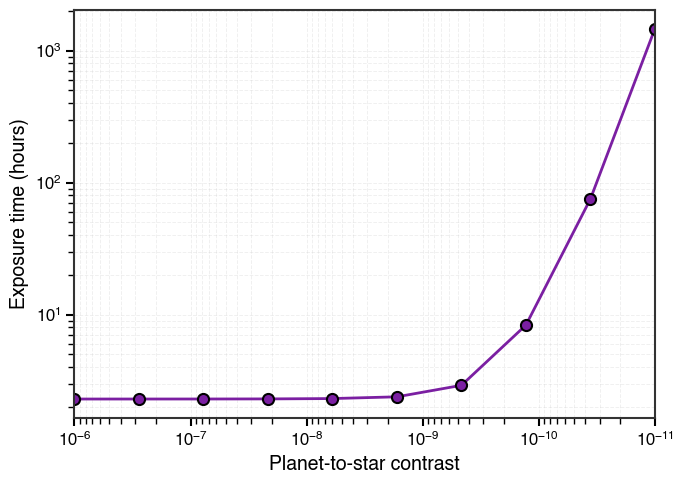

In [8]:
contrasts = np.logspace(-6, -11, 10)
exposure_times = []


for contrast in contrasts:
    params = imaging_params.copy()
    params['Fp/Fs'] = contrast
    # make the parameters be the shape that the code desires 
    texp, validation_output = calculate_texp(params)
    exposure_times.append(list(texp.values())[0]['exposure_time'].to(u.hr)) #gets first value (only one filter in this case)


# Make plot
fig, ax1 = plt.subplots()
ax1.loglog(contrasts, exposure_times, marker='o', markersize=8, linewidth=2,
             color=colors.purple, markerfacecolor=colors.purple, markeredgewidth=1.5,
             markeredgecolor='black')
ax1.set_xlim([1e-6,1e-11])
ax1.set_xlabel('Planet-to-star contrast', fontsize=14, fontweight='bold')
ax1.set_ylabel('Exposure time (hours)', fontsize=14, fontweight='bold')
ax1.tick_params(axis='both', which='major', labelsize=12, width=1.5, length=6)
ax1.tick_params(axis='both', which='minor', width=1, length=4)
ax1.grid(True, which='both', alpha=0.3, linestyle='--', linewidth=0.7)

for spine in ax1.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()



### 2.2 Distance and contrast
Let's change distance from the star and planet contrast. 

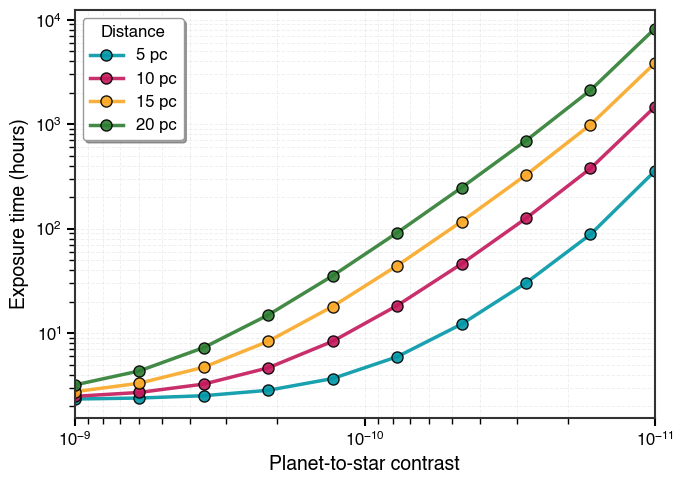

In [9]:
fig, ax = plt.subplots()
contrasts=np.logspace(-9, -11, 10)

for idx, dist in enumerate([5,10,15,20]):
    exposure_times=[]
    for contrast in np.logspace(-9, -11, 10):
        params=imaging_params.copy()
        params['Fp/Fs']=contrast
        params['distance']=dist
        # make the parameters be the shape that the code desires 
        texp, validation_output = calculate_texp(params)
        exposure_times.append(list(texp.values())[0]['exposure_time'].to(u.hr))


   
    # Primary x-axis (contrast)
    ax.loglog(contrasts, exposure_times, marker='o', linewidth=2.5, markersize=8,
              label=f'{dist} pc', color=colors[idx], markeredgewidth=1,
              markeredgecolor='black', alpha=0.9)
ax.set_xlim([1e-9,1e-11])
ax.set_xlabel('Planet-to-star contrast', fontsize=14, fontweight='medium')
ax.set_ylabel('Exposure time (hours)', fontsize=14, fontweight='medium')
ax.tick_params(axis='both', which='major', labelsize=12, width=1.5, length=6)
ax.tick_params(axis='both', which='minor', width=1, length=4)
ax.legend(frameon=True, shadow=True, fancybox=True, fontsize=12,
          title='Distance', title_fontsize=12)
ax.grid(True, which='both', alpha=0.3, linestyle='--', linewidth=0.7)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)

plt.tight_layout()


### 2.3 Separation

Now let's change the separation of the planet and see how the exposure time changes. Note: there will be some errors!

[pyEDITH] ERROR [2026-10-09 11:40:00,214] Count rate of the planet smaller than the noise floor for one or more wavelength channels. Hardcoded infinity results.


[pyEDITH] ERROR [2026-10-09 11:40:04,496] Count rate of the planet smaller than the noise floor for one or more wavelength channels. Hardcoded infinity results.


[pyEDITH] ERROR [2026-10-09 11:40:04,761] Planet outside coronagraph YIP image for one or more wavelength channels. Hardcoded infinity results.


[pyEDITH] ERROR [2026-10-09 11:40:05,037] Planet outside coronagraph YIP image for one or more wavelength channels. Hardcoded infinity results.


[pyEDITH] ERROR [2026-10-09 11:40:05,309] Planet outside coronagraph YIP image for one or more wavelength channels. Hardcoded infinity results.


[pyEDITH] ERROR [2026-10-09 11:40:05,573] Planet outside coronagraph YIP image for one or more wavelength channels. Hardcoded infinity results.


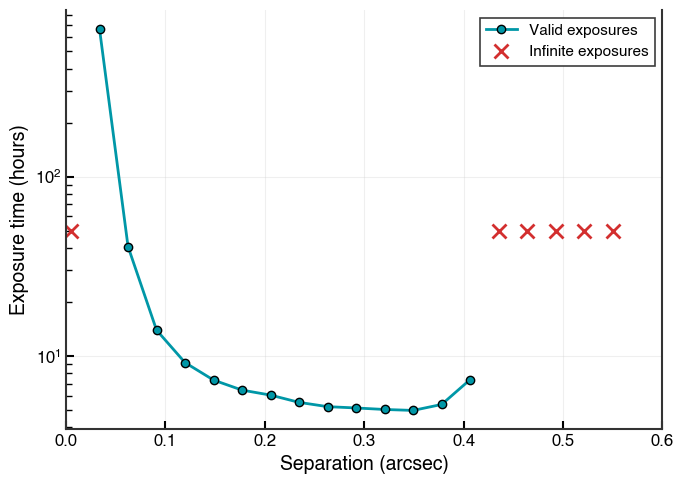

In [10]:
separations = np.linspace(0.005, 0.55, 20)  # arcsec 

exposure_times = []

for sep in separations:
    params = imaging_params.copy()
    params['separation'] = sep

    texp, _ = calculate_texp(params)
    exposure_times.append(list(texp.values())[0]['exposure_time'].to(u.hr)[0].value)

fig, ax1 = plt.subplots()

# Primary x-axis (separation arcsec)
ax1.plot(separations, exposure_times, marker='o', label='Valid exposures',
         markersize=6, linewidth=2, color=colors.cyan, markerfacecolor=colors.cyan,
         markeredgecolor='black', markeredgewidth=1)
ax1.plot(separations[np.isinf(exposure_times)],
         np.ones_like(separations)[np.isinf(exposure_times)]*50,
         marker='x', linestyle='', color=colors.red, label='Infinite exposures',
         markersize=10, markeredgewidth=2)

ax1.set_xlabel('Separation (arcsec)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Exposure time (hours)', fontsize=14, fontweight='bold')
ax1.tick_params(axis='both', which='major', labelsize=12, direction='in',
                width=1.5, length=6, top=False)
ax1.tick_params(axis='both', which='minor', direction='in', width=1,
                length=4, top=False)
ax1.set_xlim(0, 0.6)
ax1.set_yscale('log')

for spine in ['bottom','left','right']:
    ax1.spines[spine].set_visible(True)
    ax1.spines[spine].set_linewidth(1.5)


legend = ax1.legend(loc='best', frameon=True, fancybox=False, shadow=False,
                   fontsize=11, edgecolor='#333333', framealpha=0.95)
legend.get_frame().set_linewidth(1.2)

plt.tight_layout()


What if you have a planet and you want to vary the physical distance instead of calculating the corresponding separation? You can also use the keyword ``semimajor_axis'' and pyEDITH will calculate the separation internally.

[pyEDITH] ERROR [2026-10-09 11:40:05,946] Count rate of the planet smaller than the noise floor for one or more wavelength channels. Hardcoded infinity results.


[pyEDITH] ERROR [2026-10-09 11:40:08,299] Count rate of the planet smaller than the noise floor for one or more wavelength channels. Hardcoded infinity results.


[pyEDITH] ERROR [2026-10-09 11:40:08,571] Planet outside coronagraph YIP image for one or more wavelength channels. Hardcoded infinity results.


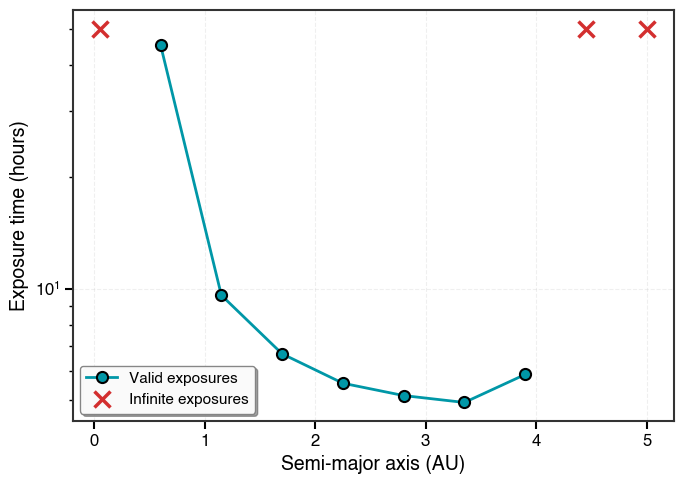

In [11]:
semimajor_axes = np.linspace(0.05, 5, 10)  # AU 

exposure_times = []

for a in semimajor_axes:
    params = imaging_params.copy()
    del params['separation']
    params['semimajor_axis'] = a 

    texp, _ = calculate_texp(params)
    exposure_times.append(list(texp.values())[0]['exposure_time'].to(u.hr)[0].value)



fig = plt.figure(dpi=100)
ax = plt.gca()
plt.plot(semimajor_axes, exposure_times, marker='o', label='Valid exposures',
         markersize=8, linewidth=2, color=colors.cyan, markerfacecolor=colors.cyan,
         markeredgecolor='black', markeredgewidth=1.5)
plt.plot(semimajor_axes[np.isinf(exposure_times)],
         np.ones_like(semimajor_axes)[np.isinf(exposure_times)]*50,
         marker='x', linestyle='', color=colors.red, label='Infinite exposures',
         markersize=12, markeredgewidth=2.5)

plt.xlabel('Semi-major axis (AU)', fontsize=14, fontweight='bold')
plt.ylabel('Exposure time (hours)', fontsize=14, fontweight='bold')
plt.tick_params(axis='both', which='major', labelsize=12, width=1.5, length=6)
plt.tick_params(axis='both', which='minor', width=1, length=3)
plt.yscale('log')

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)

plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)

plt.legend(loc='best', fontsize=11, frameon=True, shadow=True, fancybox=True,
           framealpha=0.95, edgecolor='gray')

plt.tight_layout()


### 2.4 PSF Truncation Ratio
Also, we can test the effect of varying the PSF trunction ratio. There should exist a PSF truncation ratio that minimizes exposure time and maximizes SNR (and it should be around 0.3). Let's test this:

[pyEDITH] ERROR [2026-10-09 11:40:13,724] Photometric aperture is not large enough for one or more wavelength channels. Hardcoded infinity results.


[pyEDITH] ERROR [2026-10-09 11:40:14,002] Photometric aperture is not large enough for one or more wavelength channels. Hardcoded infinity results.


[pyEDITH] ERROR [2026-10-09 11:40:14,292] Photometric aperture is not large enough for one or more wavelength channels. Hardcoded infinity results.


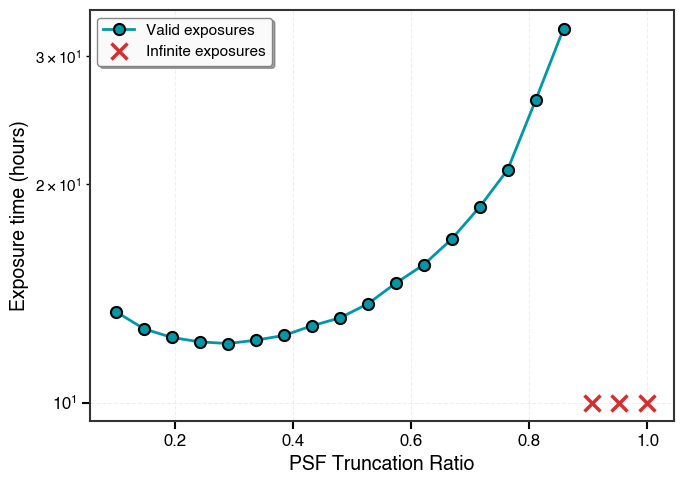

In [12]:
psfratios = np.linspace(0.1, 1, 20)   

exposure_times = []

for ratio in psfratios:
    params = imaging_params.copy()
    params['psf_trunc_ratio'] = ratio
    texp, _ = calculate_texp(params)
    exposure_times.append(list(texp.values())[0]['exposure_time'].to(u.hr)[0].value)

fig = plt.figure(dpi=100)
ax = plt.gca()
plt.semilogy(psfratios, exposure_times, marker='o', label='Valid exposures',
         markersize=8, linewidth=2, color=colors.cyan, markerfacecolor=colors.cyan,
         markeredgecolor='black', markeredgewidth=1.5)
plt.semilogy(psfratios[np.isinf(exposure_times)],
         np.ones_like(psfratios)[np.isinf(exposure_times)]*10,
         marker='x', linestyle='', color=colors.red, label='Infinite exposures',
         markersize=12, markeredgewidth=2.5)

plt.xlabel('PSF Truncation Ratio', fontsize=14, fontweight='bold')
plt.ylabel('Exposure time (hours)', fontsize=14, fontweight='bold')

plt.tick_params(axis='both', which='major', labelsize=12, width=1.5, length=6)
plt.tick_params(axis='both', which='minor', width=1, length=3)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)

plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)

plt.legend(loc='best', fontsize=11, frameon=True, shadow=True, fancybox=True,
           framealpha=0.95, edgecolor='gray')
plt.tight_layout()
plt.show()


Let's try with the SNR calculation instead.

[pyEDITH] ERROR [2026-10-09 11:40:19,328] Photometric aperture is not large enough for one or more wavelength channels. Hardcoded infinity results.


[pyEDITH] ERROR [2026-10-09 11:40:19,602] Photometric aperture is not large enough for one or more wavelength channels. Hardcoded infinity results.


[pyEDITH] ERROR [2026-10-09 11:40:19,884] Photometric aperture is not large enough for one or more wavelength channels. Hardcoded infinity results.


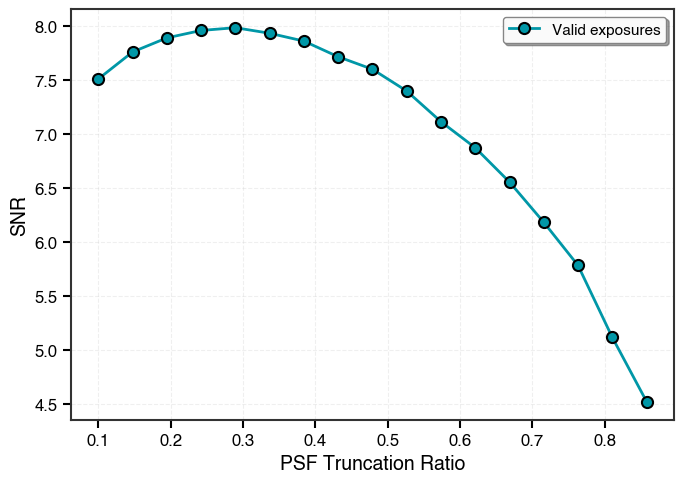

In [13]:
# SNR Case
 
psfratios = np.linspace(0.1, 1, 20)   
exptime=15*u.hr
snrs = []

for ratio in psfratios:
    params = imaging_params.copy()
    params['psf_trunc_ratio'] = ratio
    snr,_ = calculate_snr(params,exptime)
    snrs.append(list(snr.values())[0]['snr'][0].value)

# MAKE PLOT
fig = plt.figure(dpi=100)
ax = plt.gca()

plt.plot(psfratios, snrs, marker='o', label='Valid exposures',
         markersize=8, linewidth=2, color=colors.cyan, markerfacecolor=colors.cyan,
         markeredgecolor='black', markeredgewidth=1.5)

plt.xlabel('PSF Truncation Ratio', fontsize=14, fontweight='bold')
plt.ylabel('SNR', fontsize=14, fontweight='bold')

plt.tick_params(axis='both', which='major', labelsize=12, width=1.5, length=6)
plt.tick_params(axis='both', which='minor', width=1, length=3)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)

plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)

plt.legend(loc='best', fontsize=11, frameon=True, shadow=True, fancybox=True,
           framealpha=0.95, edgecolor='gray')
plt.tight_layout()
plt.show()

# SNR maximized at 0.3, just like it should! 

## 3. Advanced Usage

### 3.1 Using `pyEDITH` iteratively
In the preceding examples, we utilized the premade `calculate_texp` and `calculate_snr` functions. While this approach is straightforward, it can lead to significant performance overhead in scenarios involving repeated calculations with large parameter spaces or numerous iterations. This is because each function call reinitializes the entire calculation process.

For improved computational efficiency, particularly when dealing with extensive parameter sweeps, it is advisable to implement the loop logic within the `calculate_texp` function itself. This approach allows for targeted iteration over specific parameters while maintaining the state of other computationally intensive components.

To illustrate this optimization technique, we can examine the internal structure of the `calculate_texp` function. Refer to the `pyEDITH` workflow picture for details.

In [14]:
params = imaging_params.copy()
filters = parse_input.parse_filters(params) # parse the filters

for f in filters: # A single filter in this example, but it works with multiple filters
    # Define Observation and load relevant parameters
    observation = Observation()
    observation.load_configuration(params, filter=f)
    observation.set_output_arrays()
    observation.validate_configuration()

    # Define Astrophysical Scene and load relevant parameters,
    # then calculate zodi/exozodi
    scene = AstrophysicalScene()
    scene.load_configuration(params)
    scene.calculate_zodi_exozodi(params)
    scene.validate_configuration()

    # Create and configure Observatory
    observatory_config = parse_input.get_observatory_config(params)
    observatory = Observatory()
    observatory.create_observatory(observatory_config)
    observatory.load_configuration(params, observation, scene
    )
    observatory.validate_configuration()

    # EXPOSURE TIME CALCULATION
    calculate_exposure_time_or_snr(
        observation,
        scene,
        observatory,
        mode="exposure_time",
    )

### 3.2. Vary observatory parameters

By default, using a preset telescope or detector (e.g. `EACTelescope`, `EACDetector`) loads all parameters directly from the HWO specification files. Some parameters are **locked** by default, meaning they are owned by the specification and cannot be changed accidentally — this ensures that a standard EAC run is always internally self-consistent.

An advanced user may want to unlock specific parameters to explore the trade space (e.g. "what if the telescope were larger?" or "what if the detector had lower dark current?"). This is done by explicitly listing the parameter names in `parameters['overrides']`:

```python
params['overrides'] = ['diameter']   # only this key is unlocked
params['diameter'] = 8.0             # values without units are assumed to be
                                     # in the default unit for that parameter (meters here)
```

A few rules worth knowing before you start:

- **Only locked parameters need to appear in `overrides`.** Parameters that are already user-editable (e.g. `toverhead_fixed`) can be set directly without listing them. See the [Glossary](https://pyedith.readthedocs.io/en/latest/glossary.html) for which parameters are locked for each component.
- **If you set a locked parameter without listing it in `overrides`**, the value you supplied is silently ignored and the specification value is kept. A warning will appear in the logs — if your change seems to have no effect, increase the verbosity level and check there first. To see the full provenance of every parameter (i.e. whether each value came from the specification default or from your own input), increase the logging verbosity to DEBUG. At this level, every parameter is logged individually as it is assigned.
- **If you mistype a name in `overrides`** (e.g. `'diamter'`), an error is raised immediately. This is intentional — it prevents typos from silently doing nothing.
- **This mechanism applies to Telescope and Detector parameters only.** For coronagraph parameters that are locked by the YIP, the only way to change them is to provide a custom YIP file. See the [Coronagraph (YIP) Guide](https://pyedith.readthedocs.io/en/latest/yippy_guide.html) for how to do that.

.. danger:: 
    Overriding locked parameters breaks the internal self-consistency of the observatory configuration. Changing one parameter (e.g. `diameter`) can have physical implications for other parameters that are *not* automatically recalculated. Make sure you understand these dependencies before relying on the results. To double check exactly which values were used in a given run, increase the log verbosity to `DEBUG` (see above) to see every parameter's assignment logged individually.



### Example: impact of telescope diameter on exposure time

Here we loop over four telescope diameters and compute exposure time as a function of planet-to-star contrast. Note that `overrides` is set once outside both loops, since it does not change across iterations.


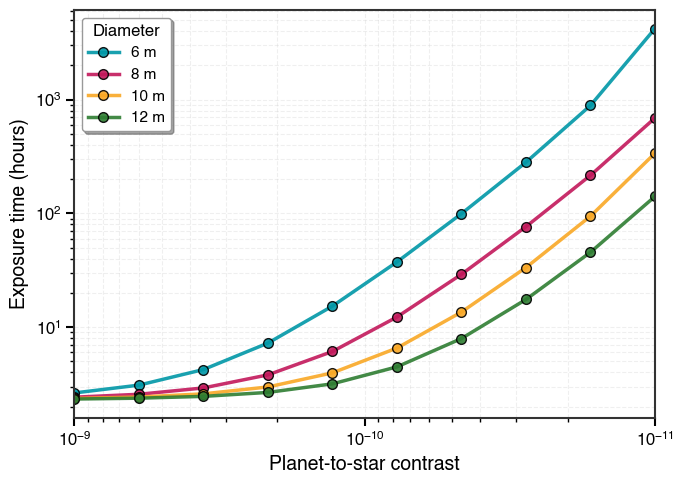

In [15]:
set_verbosity(level='quiet')


fig = plt.figure()

contrasts=np.logspace(-9, -11, 10)
params = imaging_params.copy()
params['overrides'] = ['diameter']# Defining here that this parameter will change.

for idx, diam in enumerate([6,8,10,12]):
    exposure_times=[]
    params['diameter'] = diam

    for contrast in np.logspace(-9, -11, 10):
        params['Fp/Fs']= contrast
        texp, validation_output = calculate_texp(params)
        exposure_times.append(list(texp.values())[0]['exposure_time'][0].to(u.hr).value)

    plt.loglog(contrasts, exposure_times, marker='o', label=f'{diam} m',
               markersize=7, linewidth=2.5, color=colors[idx],
               markeredgewidth=1, markeredgecolor='black', alpha=0.9)

plt.xlabel('Planet-to-star contrast', fontsize=14, fontweight='bold')
plt.ylabel('Exposure time (hours)', fontsize=14, fontweight='bold')
plt.tick_params(axis='both', which='major', labelsize=12, width=1.5, length=6)
plt.tick_params(axis='both', which='minor', width=1, length=3)
plt.xlim(1e-9,1e-11)
plt.grid(True, which='both', alpha=0.3, linestyle='--', linewidth=0.8)
plt.legend(title='Diameter', fontsize=11, title_fontsize=12, frameon=True,
           fancybox=True, shadow=True, loc='best')

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()


### Example: impact of detector dark current on exposure time

To show that the same mechanism works for detector parameters, here is an analogous sweep over dark current values. Note that `DC` appears in `overrides` this time, and `diameter` does not — the telescope stays at its EAC-default value throughout.


.. note::
`overrides` is a flat list shared across all components. A key name like `diameter` unambiguously refers to the Telescope (no Detector or Coronagraph key shares that name). If you are unsure which component owns a given parameter, consult the [Glossary](https://pyedith.readthedocs.io/en/latest/glossary.html).


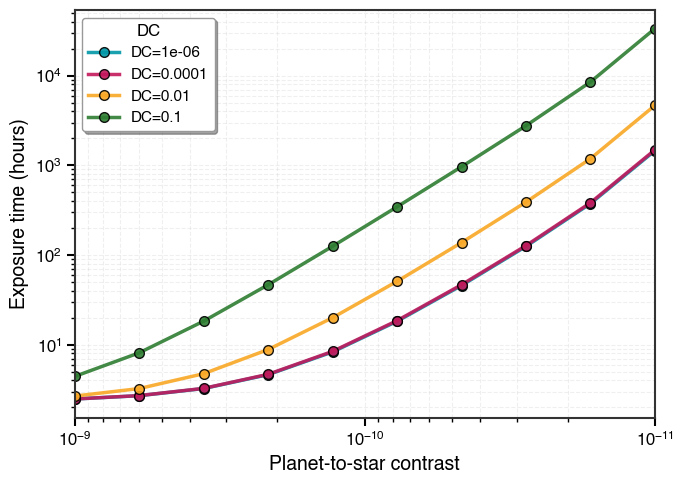

In [16]:
set_verbosity(level='quiet')

fig = plt.figure()
params = imaging_params.copy()
params['overrides'] = ['DC']         # unlocking a detector locked key this time

dark_currents = [1e-6,1e-4,1e-2,0.1]   # counts/pix/s
contrasts=np.logspace(-9, -11, 10)

for idx, dc in enumerate(dark_currents):
    exposure_times = []
    params['DC'] = dc                # interpreted as default DC unit (counts/pix/s)

    for contrast in contrasts:
        params['Fp/Fs'] = contrast
        texp, _ = calculate_texp(params)
        exposure_times.append(list(texp.values())[0]['exposure_time'][0].to(u.hr).value)

    plt.loglog(contrasts, exposure_times, marker='o', label=f'DC={dc}',
               markersize=7, linewidth=2.5, color=colors[idx],
               markeredgewidth=1, markeredgecolor='black', alpha=0.9)

plt.xlabel('Planet-to-star contrast', fontsize=14, fontweight='bold')
plt.ylabel('Exposure time (hours)', fontsize=14, fontweight='bold')
plt.tick_params(axis='both', which='major', labelsize=12, width=1.5, length=6)
plt.tick_params(axis='both', which='minor', width=1, length=3)
plt.xlim(1e-9,1e-11)
plt.grid(True, which='both', alpha=0.3, linestyle='--', linewidth=0.8)
plt.legend(title='DC', fontsize=11, title_fontsize=12, frameon=True,
           fancybox=True, shadow=True, loc='best')

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()